In [1]:
import numpy as np
import os, glob
import matplotlib.pyplot as plt

import h5py

from scipy.signal import savgol_filter

from scipy.optimize import curve_fit
from scipy.fft import rfft, irfft, rfftfreq

import sys
sys.path.append('../')
import analysis_utils as utils

import importlib

utils.load_plotting_setting()

In [16]:
data_files = [r"E:\pulse_calibration\sphere_20250406\20250412_electric_calibration_2e-8mbar_2\20250412_d_m110e_163khz_0_25vpp_trapping_0.hdf5"]
c_mvs = utils.get_c_mv(data_files, [0.25], 163000*2*np.pi, passband=(161700, 164300), charge=110, n_chunk=6, efield=138)

c_mv = np.mean(c_mvs)
print(c_mv)

7.853557241857993e-08


In [2]:
data_files = [r"E:\pulse_calibration\sphere_20250406\20250412_electric_calibration_2e-8mbar\20250412_d_m8e_163khz_1vpp_trapping_0.hdf5"]
c_mvs = utils.get_c_mv(data_files, [1], 163000*2*np.pi, passband=(161700, 164300), charge=8, n_chunk=6, efield=138)

c_mv = np.mean(c_mvs)
print(c_mv)

7.095823901233784e-08


## Long heating analysis

In [17]:
folder = r'E:\reheating_data\sphere_20250406\1_7e-8mbar'
dataset = r''
combined_path = os.path.join(folder, dataset, '20250412*.hdf5')
data_files = glob.glob(combined_path)

Quick look on the data, and choose an appropriate time window

In [ ]:
fs = 500000

file_name = data_files[5]
f = h5py.File(file_name, 'r')

zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv']/1000
ff = f['data']['channel_f'][:] * f['data']['channel_f'].attrs['adc2mv']/1000

zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)

pulse_idx = drive_indices = utils.get_pulse_idx(ff, 1, True)
f.close()

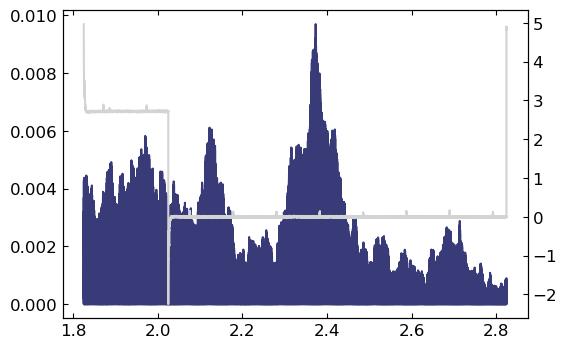

In [11]:
idx = pulse_idx[1]

tt = 2e-6 * np.arange(zz.size)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(tt[idx:idx+500000], zz_bp[idx:idx+500000]**2)
ax.twinx().plot(tt[idx:idx+500000], ff[idx:idx+500000], color='lightgrey')

Calculate ensemble averaged variance

In [8]:
def get_variance_pressure(pressure):
    folder = fr'E:\reheating_data\sphere_20250406\{pressure}'
    dataset = r''
    combined_path = os.path.join(folder, dataset, '20250412*.hdf5')
    data_files = glob.glob(combined_path)

    fs = 500000
    window_length = 500000
    var_all = []
    for file in data_files:
        f = h5py.File(file, 'r')
        zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv']/1000
        ff = f['data']['channel_f'][:] * f['data']['channel_f'].attrs['adc2mv']/1000
        f.close()

        zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)

        pulse_idx = drive_indices = utils.get_pulse_idx(ff, 1, True)
        
        for idx in pulse_idx:
            if idx > zz.size-window_length:
                continue
            var_all.append(zz_bp[idx:idx+window_length]**2)
            
    var_all = np.asarray(var_all)

    return var_all

In [18]:
pressure = ['1_7e-8mbar', '4_8e-8mbar', '9_2e-8mbar', '2_2e-7mbar']

# var_0 = get_variance_pressure(pressure[0])
# var_1 = get_variance_pressure(pressure[1])
# var_2 = get_variance_pressure(pressure[2])
var_3 = get_variance_pressure(pressure[3])

MemoryError: Unable to allocate 229. MiB for an array with shape (30000000,) and data type float64

(0.0, 2e-17)

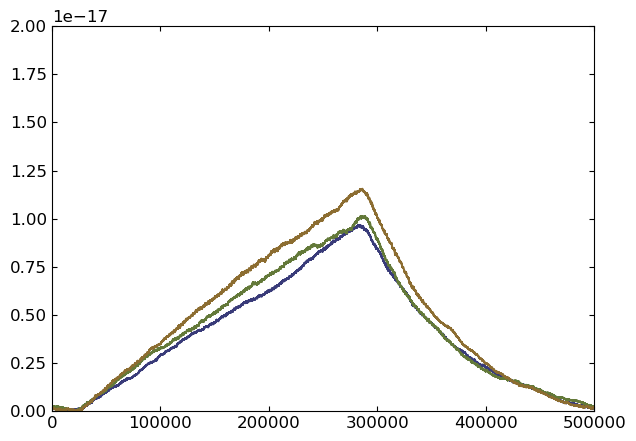

In [14]:
c_mv = 7.095823901233784e-08

for var in [var_0, var_1, var_2]:
    var_mean = np.mean(var, axis=0)
    z_var_m = var_mean * c_mv**2
    z_var_filtered = savgol_filter(z_var_m, 500, 1)

    plt.plot(z_var_filtered - np.min(z_var_filtered))

plt.xlim(0, 500000)
plt.ylim(0, 2e-17)